In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

/home/petelin/AutoTSC/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-09 12:46:02,408	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
df = (
    pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet")
    .filter(pl.col("model") != "mixed-v2")
    .filter(pl.col("model") != "mixed")
)
df

/tmp/ipykernel_1114535/3629420554.py:2: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  pl.read_parquet("s3://tsc-glue/experiments/stacking_run_v1/*.parquet")


dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""GestureMidAirD2""","""mr-hydra""",300,0.7
"""PLAID""","""quant""",300,0.947858
"""ECGFiveDays""","""rdst""",400,0.997677
"""Wafer""","""quant""",500,1.0
…,…,…,…
"""PigAirwayPressure""","""quant""",300,0.442308
"""ACSF1""","""mr-hydra""",500,0.9
"""BirdChicken""","""mixed-v4-ray""",300,0.9


In [3]:
from aeon.visualisation import plot_critical_difference

In [4]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4
str,f64,f64,f64,f64,f64,f64
"""ECG5000""",0.946222,0.943278,0.944756,0.947,0.947333,0.947022
"""GestureMidAirD2""",0.7,0.678462,0.652308,0.636538,0.626923,0.604615
"""PLAID""",0.941899,0.945624,0.935444,0.955773,0.955928,0.955307
"""ECGFiveDays""",1.0,0.997677,0.997909,0.998142,0.997677,0.997677
"""Wafer""",0.999676,1.0,1.0,0.999838,0.999919,0.999903
…,…,…,…,…,…,…
"""Herring""",0.730469,0.590625,0.6796875,0.566406,0.557292,0.5859375
"""ItalyPowerDemand""",0.969226,0.9655,0.944606,0.964431,0.96631,0.966958
"""OliveOil""",0.966667,0.933333,0.888889,0.911111,0.9,0.9


(<Figure size 600x250 with 1 Axes>, <Axes: >)

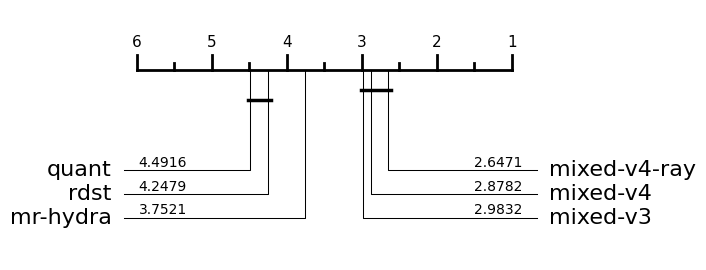

In [5]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [6]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [7]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.858268,0.867717,0.848819,0.862992,0.864173,0.862992,17,127,2,288
"""InsectEPGSmallTrain""",1.0,1.0,0.991968,1.0,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.9,0.81,0.95,0.95,0.95,0.95,20,20,2,512
"""BirdChicken""",0.9,0.9,0.9,0.9,0.9,0.9,20,20,2,512
…,…,…,…,…,…,…,…,…,…,…
"""NonInvasiveFetalECGThorax2""",0.967735,0.948397,0.940153,0.967837,0.969805,0.969466,1800,1965,42,750
"""PhalangesOutlinesCorrect""",0.845862,0.840618,0.806915,0.853147,0.853438,0.8581,1800,858,2,80
"""FordA""",0.951364,0.971364,0.949432,0.986932,0.987879,0.987727,3601,1320,2,500


59


(<Figure size 600x250 with 1 Axes>, <Axes: >)

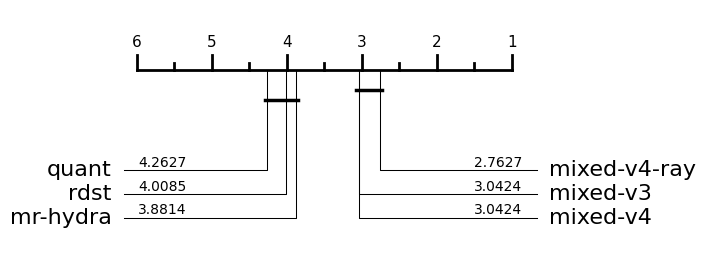

In [8]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

41


(<Figure size 600x250 with 1 Axes>, <Axes: >)

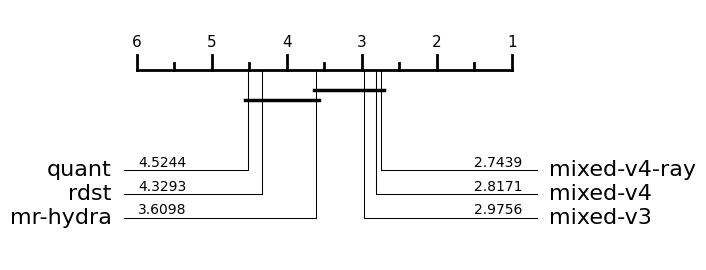

In [9]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

19


(<Figure size 600x250 with 1 Axes>, <Axes: >)

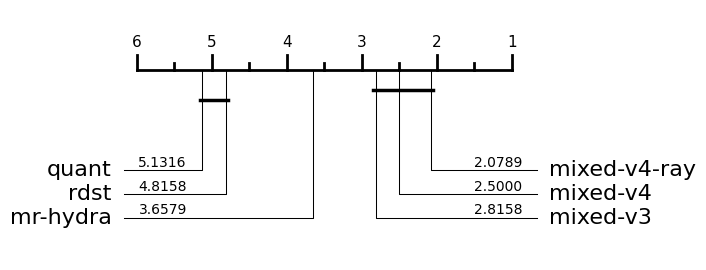

In [10]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [11]:
s_large

dataset,mr-hydra,quant,rdst,mixed-v3,mixed-v4-ray,mixed-v4,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.802899,0.788406,0.773188,0.81087,0.810688,0.800725,600,276,2,80
"""MiddlePhalanxOutlineCorrect""",0.851546,0.847938,0.839175,0.867698,0.863402,0.86323,600,291,2,80
"""ProximalPhalanxOutlineCorrect""",0.917526,0.906357,0.88488,0.915464,0.918671,0.920275,600,291,2,80
"""ShapesAll""",0.9275,0.871667,0.920667,0.924333,0.9275,0.92625,600,600,60,512
"""Strawberry""",0.974595,0.969189,0.976216,0.977297,0.975676,0.975676,613,370,2,235
…,…,…,…,…,…,…,…,…,…,…
"""NonInvasiveFetalECGThorax2""",0.967735,0.948397,0.940153,0.967837,0.969805,0.969466,1800,1965,42,750
"""PhalangesOutlinesCorrect""",0.845862,0.840618,0.806915,0.853147,0.853438,0.8581,1800,858,2,80
"""FordA""",0.951364,0.971364,0.949432,0.986932,0.987879,0.987727,3601,1320,2,500


In [13]:
import ray
ray.shutdown()